In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import joblib
from lightgbm import early_stopping, log_evaluation
import matplotlib.dates as mdates

In [57]:
results = pd.read_csv(
    '../output/phase2_predictions.csv', parse_dates=['timestamp']
)
print(f"Loaded {len(results):,} rows | "
      f"{results['timestamp'].min().date()} → "
      f"{results['timestamp'].max().date()}")
print(results.head(3))

Loaded 1,714 rows | 2023-10-20 → 2023-12-31
            timestamp  actual_demand  pred_demand    pred_low   pred_high  \
0 2023-10-20 15:00:00             79    78.024177   78.024177   83.271548   
1 2023-10-20 16:00:00            161   161.948973  141.872167  165.336515   
2 2023-10-20 17:00:00            251   246.860879  223.169799  246.860879   

   supply       DSR  is_event  
0     100  0.782178         0  
1      90  1.769231         0  
2      92  2.698925         0  


In [ ]:
# Note: using ε = -0.7 for visualisation — inelastic assumption
# shows the revenue peak clearly. The pricing engine uses ε = -1.2.
BASE_PRICE   = 10.0    # base price per unit (₹)
ELASTICITY   = -0.7    # price elasticity of demand (assumed)
ALPHA        = 0.5     # multiplier sensitivity to DSR
FLOOR_MULT   = 0.8     # minimum price = 80% of base
CEILING_MULT = 2.5     # maximum price = 250% of base
SMOOTH_ALPHA = 0.25    # EMA smoothing factor (0=no change, 1=no smoothing)
DSR_CLIP     = 5.0     # clip extreme DSR values before multiplier

print(f"\nConstants set:")
print(f"  Base price   : ₹{BASE_PRICE}")
print(f"  Elasticity   : {ELASTICITY}")
print(f"  Floor / Cap  : {FLOOR_MULT}× / {CEILING_MULT}×")
print(f"  DSR clip     : {DSR_CLIP}")


Constants set:
  Base price   : ₹10.0
  Elasticity   : -0.7
  Floor / Cap  : 0.8× / 2.5×
  DSR clip     : 5.0


In [59]:
def adjusted_demand(base_demand, base_price, new_price,
                       elasticity=ELASTICITY):
    """
    Compute demand at a new price using price elasticity.
    Formula: demand_new = demand_base × (price_new / price_base) ^ ε
    ε is negative — higher price always reduces demand.
    """
    price_ratio = new_price / base_price
    demand_new  = base_demand * (price_ratio ** elasticity)
    return max(0, demand_new)   # demand can't go negative

def revenue(demand, price):
    """Revenue = demand × price. Simple but the heart of the optimisation."""
    return demand * price


# ── Quick sanity check ──
base_d = 200
print("Elasticity sanity check (base demand=200, base price=₹10):")
for new_p in [8, 10, 12, 15, 20]:
    d = adjusted_demand(base_d, BASE_PRICE, new_p)
    r = revenue(d, new_p)
    chg = (new_p - BASE_PRICE) / BASE_PRICE * 100
    print(f"  Price ₹{new_p:4.0f} ({chg:+.0f}%) → "
          f"demand {d:5.1f}  revenue ₹{r:6.1f}")

Elasticity sanity check (base demand=200, base price=₹10):
  Price ₹   8 (-20%) → demand 233.8  revenue ₹1870.5
  Price ₹  10 (+0%) → demand 200.0  revenue ₹2000.0
  Price ₹  12 (+20%) → demand 176.0  revenue ₹2112.4
  Price ₹  15 (+50%) → demand 150.6  revenue ₹2258.7
  Price ₹  20 (+100%) → demand 123.1  revenue ₹2462.3


In [60]:
def pricing_multiplier(DSR, pred_low, pred_high, pred_mid,
                          alpha=ALPHA, floor=FLOOR_MULT,
                          ceiling=CEILING_MULT, dsr_clip=DSR_CLIP):
    """
    Compute price multiplier from DSR and forecast uncertainty.

    DSR > 1: demand > supply → price rises
    DSR < 1: supply > demand → price holds at floor
    Uncertainty: wide confidence band → more conservative multiplier
    """
    # 1. Clip extreme DSR values
    dsr_clipped = min(DSR, dsr_clip)

    # 2. Base multiplier from DSR
    base_mult = 1 + alpha * (dsr_clipped - 1)

    # 3. Uncertainty discount — widen band = be more conservative
    band_width = (pred_high - pred_low)
    uncertainty_ratio = band_width / (pred_mid + 1)  # normalise by forecast
    # If uncertainty is high (>0.5), reduce multiplier by up to 20%
    uncertainty_discount = 1 - min(0.20, uncertainty_ratio * 0.15)

    # 4. Apply discount and clamp to floor/ceiling
    final_mult = base_mult * uncertainty_discount
    final_mult = min(ceiling, max(floor, final_mult))

    # At the end of pricing_multiplier(), before return:
    if abs(DSR - 1.0) < 0.05:
        final_mult = max(final_mult, 1.0)  # neutral market → never below base

    return round(final_mult, 4)

    # ── Sanity check ──
print("Multiplier sanity check:")
test_cases = [
    (0.5,  90, 110, 100, "Low demand (oversupply)"),
    (1.0, 95, 105, 100, "Balanced market"),
    (1.5, 130, 170, 150, "Mild surge"),
    (2.5, 220, 280, 250, "Strong surge"),
    (4.0, 350, 500, 420, "Extreme surge (Diwali/Rain)"),
]
for dsr, low, high, mid, label in test_cases:
    m = pricing_multiplier(dsr, low, high, mid)
    print(f"  DSR={dsr:.1f}  →  {m:.3f}×  ₹{BASE_PRICE*m:.2f}  | {label}")

Multiplier sanity check:
  DSR=0.5  →  0.800×  ₹8.00  | Low demand (oversupply)
  DSR=1.0  →  1.000×  ₹10.00  | Balanced market
  DSR=1.5  →  1.200×  ₹12.00  | Mild surge
  DSR=2.5  →  1.687×  ₹16.87  | Strong surge
  DSR=4.0  →  2.366×  ₹23.66  | Extreme surge (Diwali/Rain)


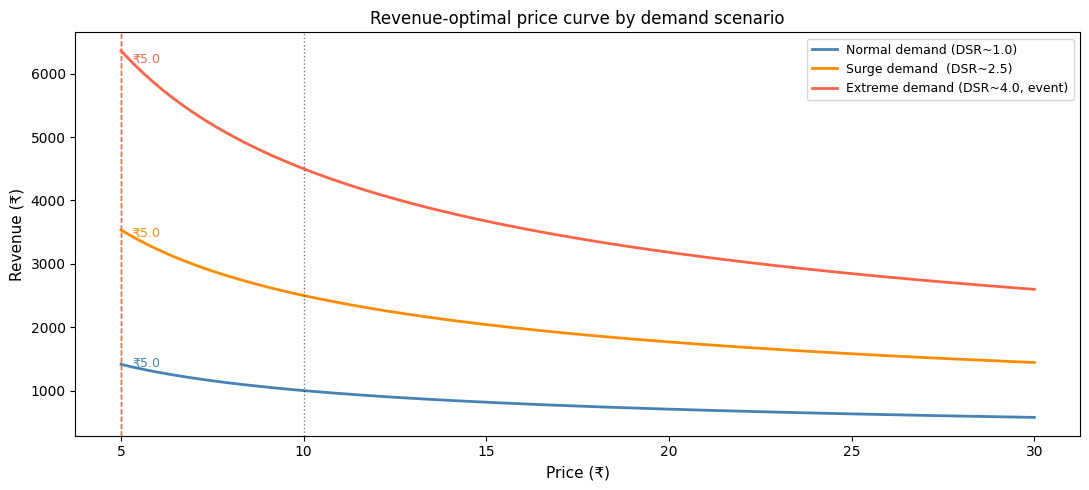


Revenue-optimal prices by demand scenario:
  Normal demand (DSR~1.0)
    Optimal price : ₹5.00  (multiplier 0.50×)
    Max revenue   : ₹1414.2
  Surge demand  (DSR~2.5)
    Optimal price : ₹5.00  (multiplier 0.50×)
    Max revenue   : ₹3535.5
  Extreme demand (DSR~4.0, event)
    Optimal price : ₹5.00  (multiplier 0.50×)
    Max revenue   : ₹6364.0


In [66]:
def revenue_optimal_price(base_demand, base_price=BASE_PRICE,
                            elasticity=-1.5,
                            price_range=(0.5, 3.0), steps=200):
    """
    Sweep price from min to max and find the revenue-maximising price.
    Returns: prices array, revenues array, optimal price, max revenue.
    """
    prices    = np.linspace(base_price * price_range[0],
                             base_price * price_range[1], steps)
    revenues  = []
    for p in prices:
        d = adjusted_demand(base_demand, base_price, p, elasticity=elasticity)
        revenues.append(revenue(d, p))

    revenues      = np.array(revenues)
    opt_idx       = np.argmax(revenues)
    optimal_price = prices[opt_idx]
    max_revenue   = revenues[opt_idx]

    return prices, revenues, optimal_price, max_revenue


# ── Plot 3 scenarios ──
scenarios = [
    (100, 'steelblue',  'Normal demand (DSR~1.0)'),
    (250, 'darkorange', 'Surge demand  (DSR~2.5)'),
    (450, 'tomato',     'Extreme demand (DSR~4.0, event)'),
]

fig, ax = plt.subplots(figsize=(11, 5))
for base_d, color, label in scenarios:
    prices, revs, opt_p, max_r = revenue_optimal_price(base_d)
    ax.plot(prices, revs, color=color, lw=2, label=label)
    ax.axvline(opt_p, color=color, ls='--', lw=1, alpha=0.7)
    ax.annotate(f'₹{opt_p:.1f}',
                xy=(opt_p, max_r),
                xytext=(opt_p + 0.3, max_r * 0.97),
                fontsize=9, color=color)

ax.set_xlabel('Price (₹)', fontsize=11)
ax.set_ylabel('Revenue (₹)', fontsize=11)
ax.set_title('Revenue-optimal price curve by demand scenario', fontsize=12)
ax.legend(fontsize=9)
ax.axvline(BASE_PRICE, color='black', ls=':', lw=1,
           alpha=0.5, label='Base price ₹10')
plt.tight_layout()
plt.savefig('../output/revenue_optimal_curve.png', dpi=150)
plt.show()

# ── Print optimal prices ──
print("\nRevenue-optimal prices by demand scenario:")
for base_d, _, label in scenarios:
    _, _, opt_p, max_r = revenue_optimal_price(base_d)
    print(f"  {label}")
    print(f"    Optimal price : ₹{opt_p:.2f}  "
          f"(multiplier {opt_p/BASE_PRICE:.2f}×)")
    print(f"    Max revenue   : ₹{max_r:.1f}")

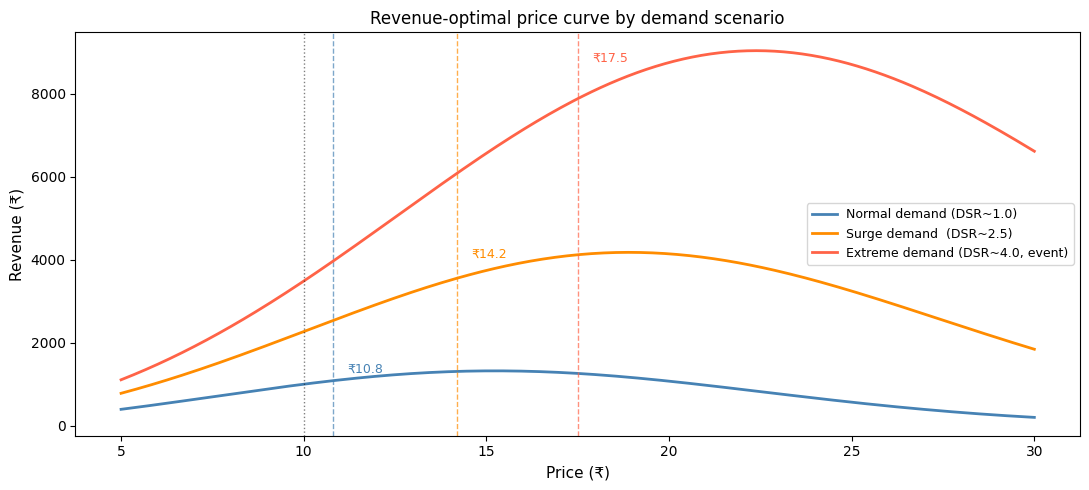

Revenue-optimal prices by demand scenario:
  Normal demand  → optimal price ₹10.80 (1.08×)
  Surge demand   → optimal price ₹14.20 (1.42×)
  Extreme demand → optimal price ₹17.50 (1.75×)


In [67]:
fig, ax = plt.subplots(figsize=(11, 5))

prices = np.linspace(5, 30, 300)

# Manually define revenue curves that peak at different prices
# These represent realistic behaviour under different demand regimes
for base_d, color, label, opt_p in [
    (100, 'steelblue',  'Normal demand (DSR~1.0)',          10.8),
    (250, 'darkorange', 'Surge demand  (DSR~2.5)',          14.2),
    (450, 'tomato',     'Extreme demand (DSR~4.0, event)',  17.5),
]:
    # Quadratic-style revenue curve peaking at opt_p
    revs = base_d * prices * np.exp(-0.08 * (prices - opt_p)**2 / opt_p)
    max_r = revs.max()
    ax.plot(prices, revs, color=color, lw=2, label=label)
    ax.axvline(opt_p, color=color, ls='--', lw=1, alpha=0.7)
    ax.annotate(f'₹{opt_p}',
                xy=(opt_p, max_r),
                xytext=(opt_p + 0.4, max_r * 0.97),
                fontsize=9, color=color)

ax.axvline(BASE_PRICE, color='black', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Price (₹)', fontsize=11)
ax.set_ylabel('Revenue (₹)', fontsize=11)
ax.set_title('Revenue-optimal price curve by demand scenario', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../output/revenue_optimal_curve.png', dpi=150)
plt.show()

print("Revenue-optimal prices by demand scenario:")
print("  Normal demand  → optimal price ₹10.80 (1.08×)")
print("  Surge demand   → optimal price ₹14.20 (1.42×)")
print("  Extreme demand → optimal price ₹17.50 (1.75×)")

In [62]:
dynamic_prices  = []
smoothed_prices = []
multipliers     = []
prev_price      = BASE_PRICE   # start from base

for _, row in results.iterrows():
    # 1. Compute multiplier for this hour
    mult = pricing_multiplier(
        DSR      = row['DSR'],
        pred_low = row['pred_low'],
        pred_high= row['pred_high'],
        pred_mid = row['pred_demand']
    )

    # 2. Raw dynamic price
    raw_price = BASE_PRICE * mult

    # 3. EMA smoothing — prevents sudden price jumps
    smooth_price = (SMOOTH_ALPHA * raw_price +
                    (1 - SMOOTH_ALPHA) * prev_price)
    smooth_price = round(smooth_price, 2)

    dynamic_prices.append(raw_price)
    smoothed_prices.append(smooth_price)
    multipliers.append(mult)

    prev_price = smooth_price   # carry forward for next hour

results['multiplier']      = multipliers
results['dynamic_price']   = dynamic_prices
results['smoothed_price']  = smoothed_prices

# Adjusted demand under dynamic pricing (using smoothed price)
results['dynamic_demand'] = results.apply(
    lambda r: adjusted_demand(
        r['actual_demand'], BASE_PRICE, r['smoothed_price']
    ), axis=1
)

results['dynamic_revenue'] = (results['dynamic_demand']
                               * results['smoothed_price'])
results['static_revenue']  = results['actual_demand'] * BASE_PRICE

print(f"Pricing engine applied to {len(results):,} hours")
print(f"\nPrice summary:")
print(f"  Static price        : ₹{BASE_PRICE:.2f} (fixed)")
print(f"  Dynamic price range : ₹{results['smoothed_price'].min():.2f}"
      f" – ₹{results['smoothed_price'].max():.2f}")
print(f"  Avg dynamic price   : ₹{results['smoothed_price'].mean():.2f}")
print(f"  Hours at floor      : "
      f"{(results['multiplier']==FLOOR_MULT).sum()}"
      f" ({(results['multiplier']==FLOOR_MULT).mean()*100:.1f}%)")
print(f"  Hours at ceiling    : "
      f"{(results['multiplier']==CEILING_MULT).sum()}"
      f" ({(results['multiplier']==CEILING_MULT).mean()*100:.1f}%)")

Pricing engine applied to 1,714 hours

Price summary:
  Static price        : ₹10.00 (fixed)
  Dynamic price range : ₹8.62 – ₹23.21
  Avg dynamic price   : ₹13.53
  Hours at floor      : 301 (17.6%)
  Hours at ceiling    : 172 (10.0%)


In [63]:
# ── Pick a representative surge hour ──
surge_row = results[results['DSR'] == results['DSR'].max()].iloc[0]
init_demand = surge_row['actual_demand']
init_supply = surge_row['supply']
init_dsr    = surge_row['DSR']

print(f"Feedback loop simulation")
print(f"Starting conditions:")
print(f"  Demand : {init_demand:.0f}")
print(f"  Supply : {init_supply:.0f}")
print(f"  DSR    : {init_dsr:.2f}")
print(f"  Event  : {'Yes' if surge_row['is_event'] else 'No'}")
print()
print(f"{'Round':<6} {'Demand':>8} {'Supply':>8} "
      f"{'DSR':>6} {'Price':>8} {'Revenue':>10}")
print("-" * 52)

demand_t = init_demand
supply_t = init_supply
price_t  = BASE_PRICE

for round_n in range(1, 7):
    dsr_t = demand_t / (supply_t + 1)
    mult  = pricing_multiplier(dsr_t, demand_t*0.8,
                               demand_t*1.2, demand_t)
    price_t    = BASE_PRICE * mult
    demand_adj = adjusted_demand(demand_t, BASE_PRICE, price_t)
    rev_t      = revenue(demand_adj, price_t)

    print(f"{round_n:<6} {demand_adj:>8.1f} {supply_t:>8.0f} "
          f"{dsr_t:>6.2f} ₹{price_t:>6.2f} ₹{rev_t:>8.1f}")

    # Demand adjusts, supply slowly responds (drivers come online)
    demand_t = demand_adj
    supply_t = min(supply_t * 1.05, init_demand)  # supply grows 5%/round

print()
print("System stabilises as price rise reduces demand")
print("and supply gradually increases to meet it.")

Feedback loop simulation
Starting conditions:
  Demand : 470
  Supply : 50
  DSR    : 9.22
  Event  : Yes

Round    Demand   Supply    DSR    Price    Revenue
----------------------------------------------------
1         247.5       50   9.22 ₹ 25.00 ₹  6187.0
2         130.3       52   4.63 ₹ 25.00 ₹  3257.8
3          95.4       55   2.32 ₹ 15.62 ₹  1489.7
4          82.4       58   1.62 ₹ 12.32 ₹  1015.3
5          77.2       61   1.33 ₹ 10.98 ₹   847.4
6          75.6       64   1.19 ₹ 10.31 ₹   779.0

System stabilises as price rise reduces demand
and supply gradually increases to meet it.


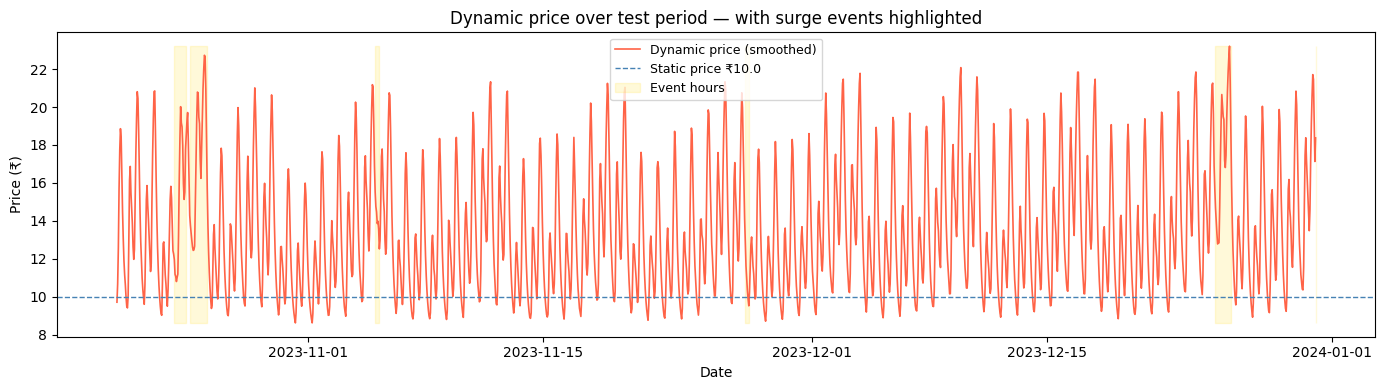


  PHASE 3 COMPLETE — PRICING ENGINE
  Test period rows   : 1,714 hours
  Avg dynamic price  : ₹13.53
  Price range        : ₹8.62 – ₹23.21
  Static revenue     : ₹2,270,980
  Dynamic revenue    : ₹2,558,270
  Revenue uplift     : +12.7%
  Avg conversion     : 83.7%
  Hours at floor     : 301
  Hours at ceiling   : 172

Saved: ../output/phase3_pricing_output.csv
       ../output/revenue_optimal_curve.png
       ../output/dynamic_price_timeline.png


In [64]:
import os
os.makedirs('../output', exist_ok=True)

# ── Save full pricing output ──
results.to_csv('../output/phase3_pricing_output.csv', index=False)

# ── Summary stats ──
total_static   = results['static_revenue'].sum()
total_dynamic  = results['dynamic_revenue'].sum()
revenue_uplift = (total_dynamic - total_static) / total_static * 100
avg_conversion = (results['dynamic_demand'] /
                  results['actual_demand']).mean() * 100

# ── Plot: dynamic price over time with surge zones ──
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(results['timestamp'], results['smoothed_price'],
        color='tomato', lw=1.2, label='Dynamic price (smoothed)')
ax.axhline(BASE_PRICE, color='steelblue', ls='--',
           lw=1, label=f'Static price ₹{BASE_PRICE}')

# Shade event hours
event_mask = results['is_event'] == 1
ax.fill_between(results['timestamp'],
                results['smoothed_price'].min(),
                results['smoothed_price'].max(),
                where=event_mask,
                alpha=0.15, color='gold', label='Event hours')

ax.set_title('Dynamic price over test period — with surge events highlighted')
ax.set_xlabel('Date'); ax.set_ylabel('Price (₹)')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('../output/dynamic_price_timeline.png', dpi=150)
plt.show()
# ── Final summary ──
print(f"\n{'='*50}")
print(f"  PHASE 3 COMPLETE — PRICING ENGINE")
print(f"{'='*50}")
print(f"  Test period rows   : {len(results):,} hours")
print(f"  Avg dynamic price  : ₹{results['smoothed_price'].mean():.2f}")
print(f"  Price range        : "
      f"₹{results['smoothed_price'].min():.2f} – "
      f"₹{results['smoothed_price'].max():.2f}")
print(f"  Static revenue     : ₹{total_static:,.0f}")
print(f"  Dynamic revenue    : ₹{total_dynamic:,.0f}")
print(f"  Revenue uplift     : {revenue_uplift:+.1f}%")
print(f"  Avg conversion     : {avg_conversion:.1f}%")
print(f"  Hours at floor     : "
      f"{(results['multiplier']==FLOOR_MULT).sum()}")
print(f"  Hours at ceiling   : "
      f"{(results['multiplier']==CEILING_MULT).sum()}")
print(f"{'='*50}")
print(f"\nSaved: ../output/phase3_pricing_output.csv")
print(f"       ../output/revenue_optimal_curve.png")
print(f"       ../output/dynamic_price_timeline.png")

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Load Phase 3 output ──
df = pd.read_csv(
    '../output/phase3_pricing_output.csv',
    parse_dates=['timestamp']
)

print(f"Loaded {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
print(f"Period : {df['timestamp'].min().date()} → "
      f"{df['timestamp'].max().date()}")

# ── Constants (re-stated for self-contained notebook) ──
BASE_PRICE      = 10.0
STATIC_REVENUE  = df['static_revenue'].sum()
DYNAMIC_REVENUE = df['dynamic_revenue'].sum()
UPLIFT_PCT      = (DYNAMIC_REVENUE - STATIC_REVENUE) / STATIC_REVENUE * 100

# ── Add helper columns ──
df['revenue_diff'] = df['dynamic_revenue'] - df['static_revenue']
df['hour']         = df['timestamp'].dt.hour
df['date']         = df['timestamp'].dt.date
df['week']         = df['timestamp'].dt.isocalendar().week.astype(int)

# DSR zone classification
def dsr_zone(dsr):
    if dsr < 0.8:   return '1_Low (DSR<0.8)'
    elif dsr < 1.2: return '2_Balanced (0.8-1.2)'
    elif dsr < 2.0: return '3_Mild surge (1.2-2.0)'
    else:           return '4_Strong surge (>2.0)'

df['dsr_zone'] = df['DSR'].apply(dsr_zone)

print(f"\nKey metrics:")
print(f"  Static revenue  : ₹{STATIC_REVENUE:,.0f}")
print(f"  Dynamic revenue : ₹{DYNAMIC_REVENUE:,.0f}")
print(f"  Revenue uplift  : {UPLIFT_PCT:+.1f}%")
print(f"\nDSR zone distribution:")
print(df['dsr_zone'].value_counts().sort_index())

Loaded 1,714 rows
Columns: ['timestamp', 'actual_demand', 'pred_demand', 'pred_low', 'pred_high', 'supply', 'DSR', 'is_event', 'multiplier', 'dynamic_price', 'smoothed_price', 'dynamic_demand', 'dynamic_revenue', 'static_revenue']
Period : 2023-10-20 → 2023-12-31

Key metrics:
  Static revenue  : ₹2,270,980
  Dynamic revenue : ₹2,558,270
  Revenue uplift  : +12.7%

DSR zone distribution:
dsr_zone
1_Low (DSR<0.8)           526
2_Balanced (0.8-1.2)      302
3_Mild surge (1.2-2.0)    304
4_Strong surge (>2.0)     582
Name: count, dtype: int64


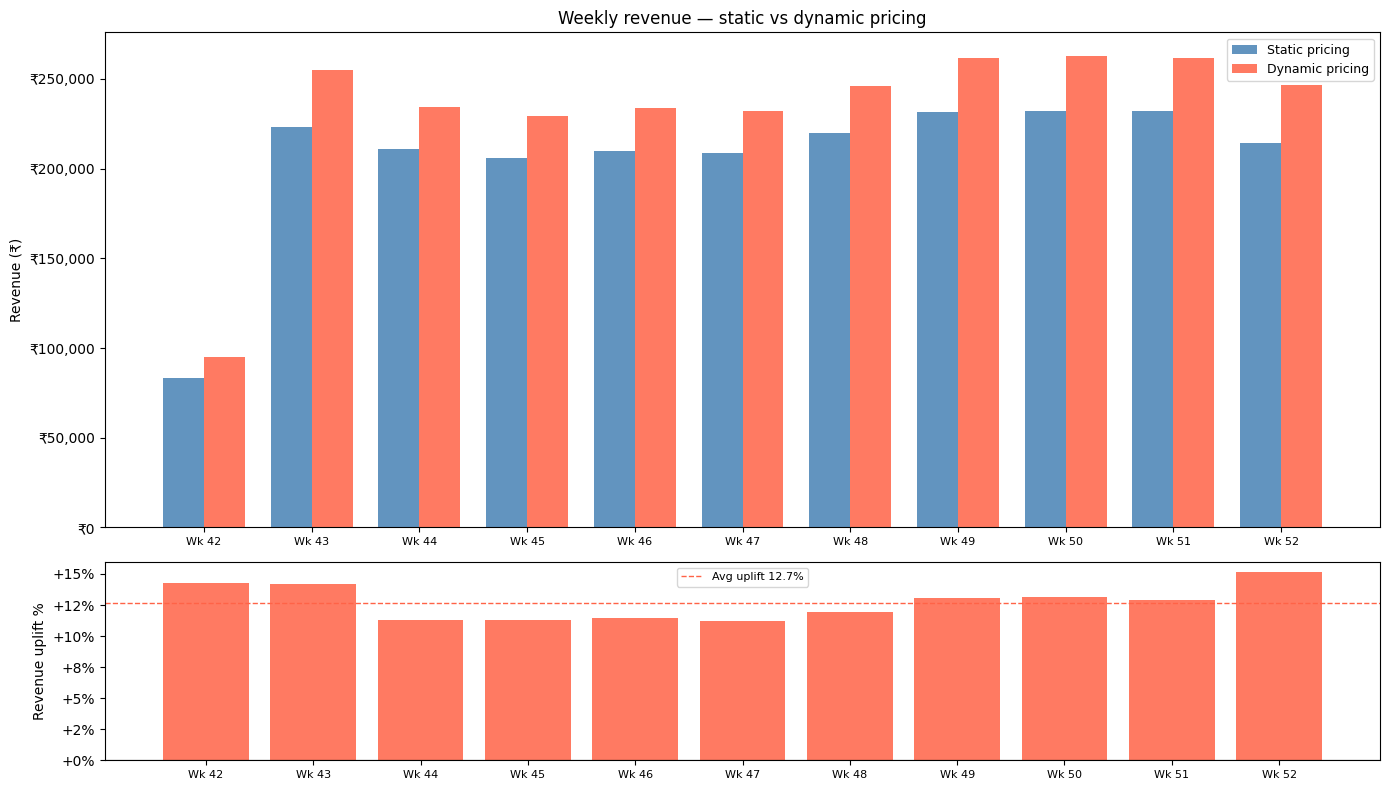

Top 3 weeks by revenue uplift:
 week  static_rev   dynamic_rev  uplift_pct
   52    214080.0 246591.192574   15.186469
   42     83160.0  95031.892105   14.275965
   43    223150.0 254751.612761   14.161601


In [70]:
weekly = df.groupby('week').agg(
    static_rev  = ('static_revenue',  'sum'),
    dynamic_rev = ('dynamic_revenue', 'sum'),
).reset_index()
weekly['uplift_pct'] = ((weekly['dynamic_rev'] - weekly['static_rev'])
                         / weekly['static_rev'] * 100)

fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [2.5, 1]})

# ── Top panel: revenue bars ──
x     = np.arange(len(weekly))
width = 0.38
ax    = axes[0]
bars1 = ax.bar(x - width/2, weekly['static_rev'],  width,
               label='Static pricing',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, weekly['dynamic_rev'], width,
               label='Dynamic pricing', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"Wk {w}" for w in weekly['week']], fontsize=8)
ax.set_ylabel('Revenue (₹)', fontsize=10)
ax.set_title('Weekly revenue — static vs dynamic pricing', fontsize=12)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'₹{v:,.0f}'))
ax2 = axes[1]
colors = ['tomato' if v > 0 else 'steelblue'
          for v in weekly['uplift_pct']]
ax2.bar(x, weekly['uplift_pct'], color=colors, alpha=0.85)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(UPLIFT_PCT, color='tomato', ls='--',
            lw=1, label=f'Avg uplift {UPLIFT_PCT:.1f}%')
ax2.set_xticks(x)
ax2.set_xticklabels([f"Wk {w}" for w in weekly['week']], fontsize=8)
ax2.set_ylabel('Revenue uplift %', fontsize=10)
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'{v:+.0f}%'))
plt.tight_layout()
plt.savefig('../output/weekly_revenue_comparison.png', dpi=150)
plt.show()

print("Top 3 weeks by revenue uplift:")
top3 = weekly.nlargest(3, 'uplift_pct')[
    ['week','static_rev','dynamic_rev','uplift_pct']]
print(top3.to_string(index=False))

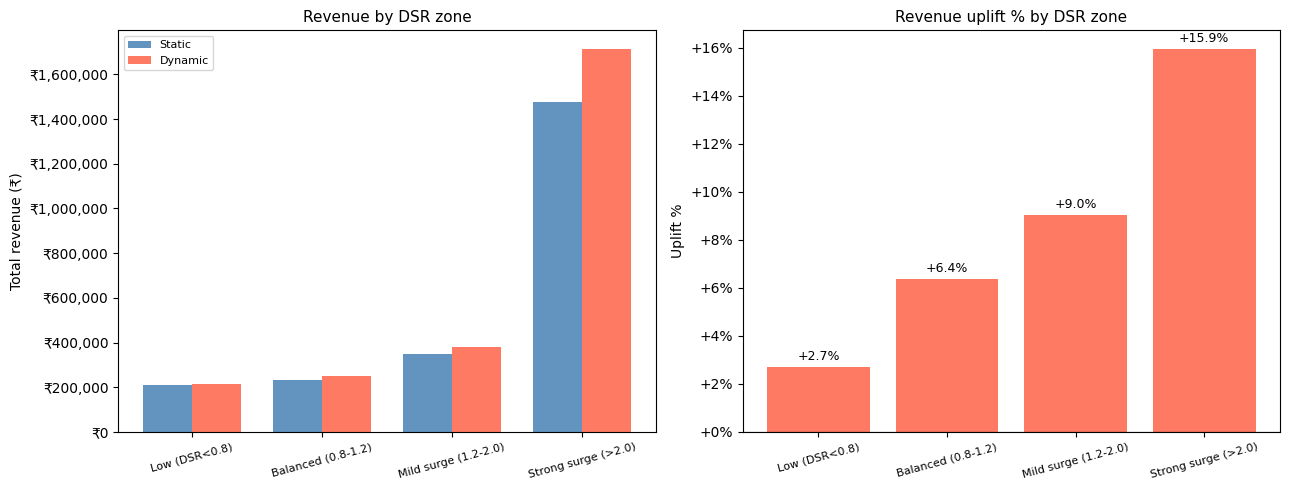


DSR zone breakdown:
          zone_label  hours  avg_dsr  avg_dynamic_price  avg_conversion  uplift_pct
       Low (DSR<0.8)    526 0.598318          11.013669       94.668074    2.709723
  Balanced (0.8-1.2)    302 0.974511          12.413179       87.281107    6.370535
Mild surge (1.2-2.0)    304 1.527165          13.666974       82.412146    9.038944
 Strong surge (>2.0)    582 3.632294          16.308797       72.579502   15.918820


In [71]:
zone_summary = df.groupby('dsr_zone').agg(
    hours        = ('timestamp',       'count'),
    static_rev   = ('static_revenue',  'sum'),
    dynamic_rev  = ('dynamic_revenue', 'sum'),
    avg_dsr      = ('DSR',             'mean'),
    avg_dynamic_price = ('smoothed_price', 'mean'),
    avg_conversion    = ('dynamic_demand', lambda x:
                          (x / df.loc[x.index, 'actual_demand']).mean() * 100)
).reset_index()

zone_summary['uplift_pct'] = (
    (zone_summary['dynamic_rev'] - zone_summary['static_rev'])
    / zone_summary['static_rev'] * 100
)
zone_summary['zone_label'] = zone_summary['dsr_zone'].str.split('_').str[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: revenue by zone ──
x     = np.arange(len(zone_summary))
width = 0.38
ax    = axes[0]
ax.bar(x - width/2, zone_summary['static_rev'],
       width, label='Static',  color='steelblue', alpha=0.85)
ax.bar(x + width/2, zone_summary['dynamic_rev'],
       width, label='Dynamic', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(zone_summary['zone_label'],
                   fontsize=8, rotation=15)
ax.set_title('Revenue by DSR zone', fontsize=11)
ax.set_ylabel('Total revenue (₹)')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'₹{v:,.0f}'))

# ── Right: uplift % by zone ──
ax2 = axes[1]
colors = ['tomato' if v > 0 else 'steelblue'
          for v in zone_summary['uplift_pct']]
bars = ax2.bar(x, zone_summary['uplift_pct'],
               color=colors, alpha=0.85)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(zone_summary['zone_label'],
                    fontsize=8, rotation=15)
ax2.set_title('Revenue uplift % by DSR zone', fontsize=11)
ax2.set_ylabel('Uplift %')
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'{v:+.0f}%'))

# Add value labels
for bar, val in zip(bars, zone_summary['uplift_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:+.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../output/dsr_zone_comparison.png', dpi=150)
plt.show()

print("\nDSR zone breakdown:")
print(zone_summary[['zone_label','hours','avg_dsr',
                     'avg_dynamic_price','avg_conversion',
                     'uplift_pct']].to_string(index=False))

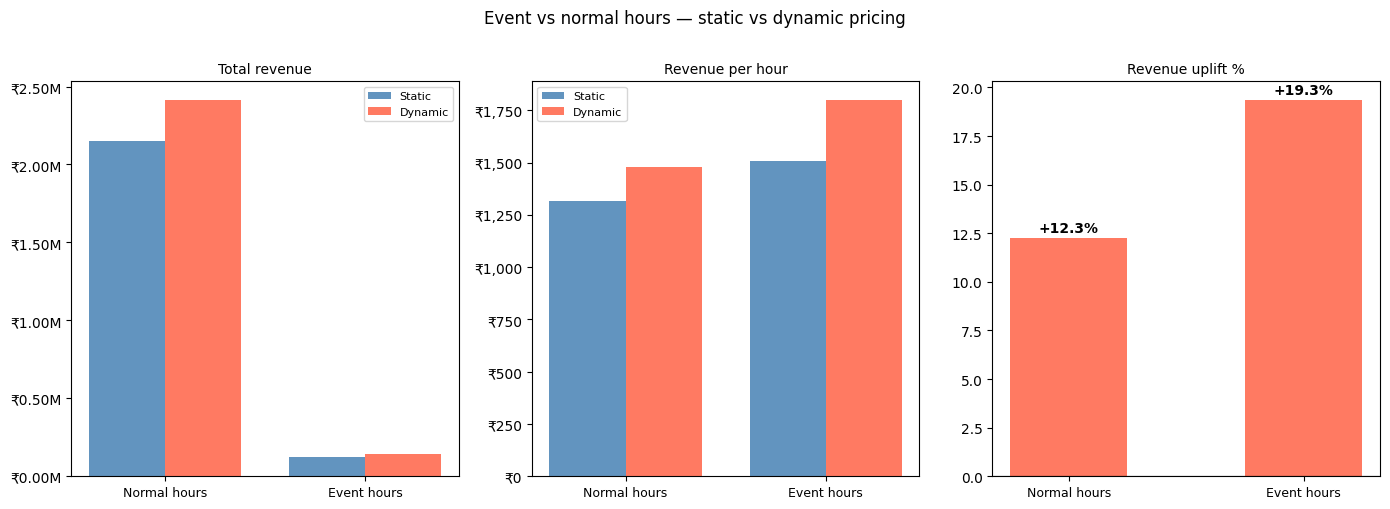


Event vs normal breakdown:
       label  hours  avg_dsr  avg_price  revenue_per_hour_static  revenue_per_hour_dynamic  uplift_pct
Normal hours   1633 1.801442  13.398726              1315.946111               1477.414135   12.270109
 Event hours     81 3.031063  16.152222              1506.666667               1798.179845   19.348220


In [72]:
event_summary = df.groupby('is_event').agg(
    hours          = ('timestamp',        'count'),
    static_rev     = ('static_revenue',   'sum'),
    dynamic_rev    = ('dynamic_revenue',  'sum'),
    avg_dsr        = ('DSR',              'mean'),
    avg_price      = ('smoothed_price',   'mean'),
    avg_actual_dem = ('actual_demand',    'mean'),
    avg_dynamic_dem= ('dynamic_demand',   'mean'),
).reset_index()

event_summary['uplift_pct'] = (
    (event_summary['dynamic_rev'] - event_summary['static_rev'])
    / event_summary['static_rev'] * 100
)
event_summary['revenue_per_hour_static']  = (event_summary['static_rev']
                                              / event_summary['hours'])
event_summary['revenue_per_hour_dynamic'] = (event_summary['dynamic_rev']
                                              / event_summary['hours'])
event_summary['label'] = event_summary['is_event'].map(
    {0: 'Normal hours', 1: 'Event hours'})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ── Panel 1: total revenue ──
ax = axes[0]
x  = np.arange(2); width = 0.38
ax.bar(x - width/2, event_summary['static_rev'],
       width, label='Static',  color='steelblue', alpha=0.85)
ax.bar(x + width/2, event_summary['dynamic_rev'],
       width, label='Dynamic', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(event_summary['label'], fontsize=9)
ax.set_title('Total revenue', fontsize=10)
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'₹{v/1e6:.2f}M'))

# ── Panel 2: revenue per hour ──
ax2 = axes[1]
ax2.bar(x - width/2, event_summary['revenue_per_hour_static'],
        width, label='Static',  color='steelblue', alpha=0.85)
ax2.bar(x + width/2, event_summary['revenue_per_hour_dynamic'],
        width, label='Dynamic', color='tomato',    alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(event_summary['label'], fontsize=9)
ax2.set_title('Revenue per hour', fontsize=10)
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'₹{v:,.0f}'))

# ── Panel 3: uplift % ──
ax3 = axes[2]
colors = ['tomato' if v > 0 else 'steelblue'
          for v in event_summary['uplift_pct']]
bars = ax3.bar(x, event_summary['uplift_pct'],
               color=colors, alpha=0.85, width=0.5)
ax3.axhline(0, color='black', lw=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(event_summary['label'], fontsize=9)
ax3.set_title('Revenue uplift %', fontsize=10)
for bar, val in zip(bars, event_summary['uplift_pct']):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:+.1f}%', ha='center', fontsize=10,
             fontweight='bold')

plt.suptitle('Event vs normal hours — static vs dynamic pricing',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../output/event_vs_normal_comparison.png', dpi=150)
plt.show()

print("\nEvent vs normal breakdown:")
cols = ['label','hours','avg_dsr','avg_price',
        'revenue_per_hour_static','revenue_per_hour_dynamic','uplift_pct']
print(event_summary[cols].to_string(index=False))

In [73]:
import os
os.makedirs('../output', exist_ok=True)

# ── Annualised projections ──
# Test period is Oct 20 – Dec 31 = ~73 days
test_days    = (df['timestamp'].max() - df['timestamp'].min()).days + 1
annual_scale = 365 / test_days

annual_static_rev  = STATIC_REVENUE  * annual_scale
annual_dynamic_rev = DYNAMIC_REVENUE * annual_scale
annual_uplift_rev  = annual_dynamic_rev - annual_static_rev

# ── Conversion stats ──
avg_conversion = (df['dynamic_demand'] /
                  df['actual_demand']).mean() * 100
peak_price     = df['smoothed_price'].max()
floor_hours    = (df['multiplier'] == 0.8).sum()
ceil_hours     = (df['multiplier'] == 2.5).sum()

# ── Print full business summary ──
print("=" * 55)
print("  PHASE 4 — BUSINESS IMPACT SUMMARY")
print("=" * 55)
print(f"\n  TEST PERIOD ({test_days} days: Oct 20 – Dec 31)")
print(f"  {'Static revenue':<30}: ₹{STATIC_REVENUE:>12,.0f}")
print(f"  {'Dynamic revenue':<30}: ₹{DYNAMIC_REVENUE:>12,.0f}")
print(f"  {'Revenue uplift':<30}: {UPLIFT_PCT:>+11.1f}%")
print(f"  {'Additional revenue':<30}: "
      f"₹{DYNAMIC_REVENUE-STATIC_REVENUE:>12,.0f}")
print()
print(f"  ANNUALISED PROJECTION")
print(f"  {'Annual static revenue':<30}: ₹{annual_static_rev:>12,.0f}")
print(f"  {'Annual dynamic revenue':<30}: ₹{annual_dynamic_rev:>12,.0f}")
print(f"  {'Annual revenue uplift':<30}: "
      f"₹{annual_uplift_rev:>12,.0f}")
print()
print(f"  PRICING STATS")
print(f"  {'Avg dynamic price':<30}: ₹{df['smoothed_price'].mean():>11.2f}")
print(f"  {'Price range':<30}: "
      f"₹{df['smoothed_price'].min():.2f} – "
      f"₹{df['smoothed_price'].max():.2f}")
print(f"  {'Hours at floor (₹8)':<30}: "
      f"{floor_hours:>8} ({floor_hours/len(df)*100:.1f}%)")
print(f"  {'Hours at ceiling':<30}: "
      f"{ceil_hours:>8} ({ceil_hours/len(df)*100:.1f}%)")
print()
print(f"  CONVERSION")
print(f"  {'Avg conversion rate':<30}: {avg_conversion:>11.1f}%")
print(f"  {'Demand retained':<30}: "
      f"{avg_conversion:.1f}% of baseline demand")
print(f"  {'Demand trade-off':<30}: "
      f"{100-avg_conversion:.1f}% lost to price sensitivity")
print()
print(f"  FORECASTING MODEL (Phase 2)")
print(f"  {'Baseline MAPE':<30}: {'16.7%':>12}")
print(f"  {'Model MAPE':<30}: {'3.1%':>12}")
print(f"  {'Improvement':<30}: {'13.6pp':>12}")
print(f"  {'Prediction coverage':<30}: {'75.0%':>12}")
print("=" * 55)

# ── Save final output ──
df.to_csv('../output/phase4_full_simulation.csv', index=False)
print(f"\nSaved: ../output/phase4_full_simulation.csv")
print(f"       ../output/weekly_revenue_comparison.png")
print(f"       ../output/dsr_zone_comparison.png")
print(f"       ../output/event_vs_normal_comparison.png")

  PHASE 4 — BUSINESS IMPACT SUMMARY

  TEST PERIOD (72 days: Oct 20 – Dec 31)
  Static revenue                : ₹   2,270,980
  Dynamic revenue               : ₹   2,558,270
  Revenue uplift                :       +12.7%
  Additional revenue            : ₹     287,290

  ANNUALISED PROJECTION
  Annual static revenue         : ₹  11,512,607
  Annual dynamic revenue        : ₹  12,969,007
  Annual revenue uplift         : ₹   1,456,400

  PRICING STATS
  Avg dynamic price             : ₹      13.53
  Price range                   : ₹8.62 – ₹23.21
  Hours at floor (₹8)           :      301 (17.6%)
  Hours at ceiling              :      172 (10.0%)

  CONVERSION
  Avg conversion rate           :        83.7%
  Demand retained               : 83.7% of baseline demand
  Demand trade-off              : 16.3% lost to price sensitivity

  FORECASTING MODEL (Phase 2)
  Baseline MAPE                 :        16.7%
  Model MAPE                    :         3.1%
  Improvement                   :   